# **Hands-on Lab : Web Scraping**


## Objectives


* Extract information from a given web site 
* Write the scraped data into a csv file.


## Extract information from the given web site


## Extract information from the given web site


In [1]:
#this url contains the data you need to scrape
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

The data you need to scrape is the **name of the programming language** and **average annual salary**.<br> It is a good idea to open the url in your web broswer and study the contents of the web page before you start to scrape.


Import the required libraries


In [2]:
from bs4 import BeautifulSoup # this module helps in web scrapping.
import requests  # this module helps us to download a webpage
import pandas as pd

Download the webpage at the url


In [3]:
import requests

# URL containing the data
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

# Send a GET request to download the webpage
response = requests.get(url)

# Check if the request was successful
if response.ok:
    # Store the HTML content in a variable
    data = response.text
    print("Webpage downloaded successfully!")
else:
    print("Failed to download the webpage. Status code:", response.status_code)

Webpage downloaded successfully!


Create a soup object


In [5]:
from bs4 import BeautifulSoup

# Assuming 'data' contains the HTML content
soup = BeautifulSoup(data, "html.parser")

# Verify by printing the first 500 characters of the parsed HTML
print(soup.prettify()[:500])

<!DOCTYPE html>
<html lang="en">
 <head>
  <title>
   Salary survey results of programming languages
  </title>
  <style>
   table, th, td {
  border: 1px solid black;
}
  </style>
 </head>
 <body>
  <hr/>
  <h2>
   Popular Programming Languages
  </h2>
  <hr/>
  <p>
   Finding out which is the best language is a tough task. A programming language is created to solve a specific problem. A language which is good for task A may not be able to properly handle task B. Comparing programming language 


Scrape the `Language name` and `annual average salary`.


In [13]:
from bs4 import BeautifulSoup
import requests
import pandas as pd

# URL
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

# Download webpage
data = requests.get(url).text

# Parse HTML
soup = BeautifulSoup(data, "html.parser")

# Find the first table
table = soup.find("table")

# Convert HTML table to DataFrame
df = pd.read_html(str(table))[0]

print (df.head())

# Convert all column names to strings, then strip whitespace
df.columns = [str(col).strip() for col in df.columns]

# Check column names
print("Columns found:", df.columns.tolist())


# Select first two columns (Language and Salary)
#df_salary = df[df.columns[:2]]
df_salary = df[df.columns[[1,3]]]
# Rename columns for clarity
df_salary.columns = ["Language", "Average Annual Salary"]

df_salary = df_salary[1:]

# Display first rows
print(df_salary.head())

# Save to CSV
df_salary.to_csv("popular-languages.csv", index=False)
print("Data saved to popular-languages.csv successfully!")


     0           1                             2                      3  \
0  No.    Language                    Created By  Average Annual Salary   
1    1      Python              Guido van Rossum               $114,383   
2    2        Java                 James Gosling               $101,013   
3    3           R  Robert Gentleman, Ross Ihaka                $92,037   
4    4  Javascript                      Netscape               $110,981   

                     4  
0  Learning Difficulty  
1                 Easy  
2                 Easy  
3                 Hard  
4                 Easy  
Columns found: ['0', '1', '2', '3', '4']
     Language Average Annual Salary
1      Python              $114,383
2        Java              $101,013
3           R               $92,037
4  Javascript              $110,981
5       Swift              $130,801
Data saved to popular-languages.csv successfully!


Save the scrapped data into a file named *popular-languages.csv*


In [8]:
# Save the scraped data to a CSV file
df_salary.to_csv("popular-languages.csv", index=False)

print("Data saved to popular-languages.csv successfully!")

Data saved to popular-languages.csv successfully!


In [ ]:
#Extracting rows usig for loop

     0           1                             2                      3  \
0  No.    Language                    Created By  Average Annual Salary   
1    1      Python              Guido van Rossum               $114,383   
2    2        Java                 James Gosling               $101,013   
3    3           R  Robert Gentleman, Ross Ihaka                $92,037   
4    4  Javascript                      Netscape               $110,981   

                     4  
0  Learning Difficulty  
1                 Easy  
2                 Easy  
3                 Hard  
4                 Easy  
0 No.    Language                    Created By Average Annual Salary  \
1   1      Python              Guido van Rossum              $114,383   
2   2        Java                 James Gosling              $101,013   
3   3           R  Robert Gentleman, Ross Ihaka               $92,037   
4   4  Javascript                      Netscape              $110,981   
5   5       Swift                 

/home/jupyterlab/conda/envs/python/lib/python3.7/site-packages/ipykernel_launcher.py:58: UserWarning: Glyph 9 (	) missing from current font.
/home/jupyterlab/conda/envs/python/lib/python3.7/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


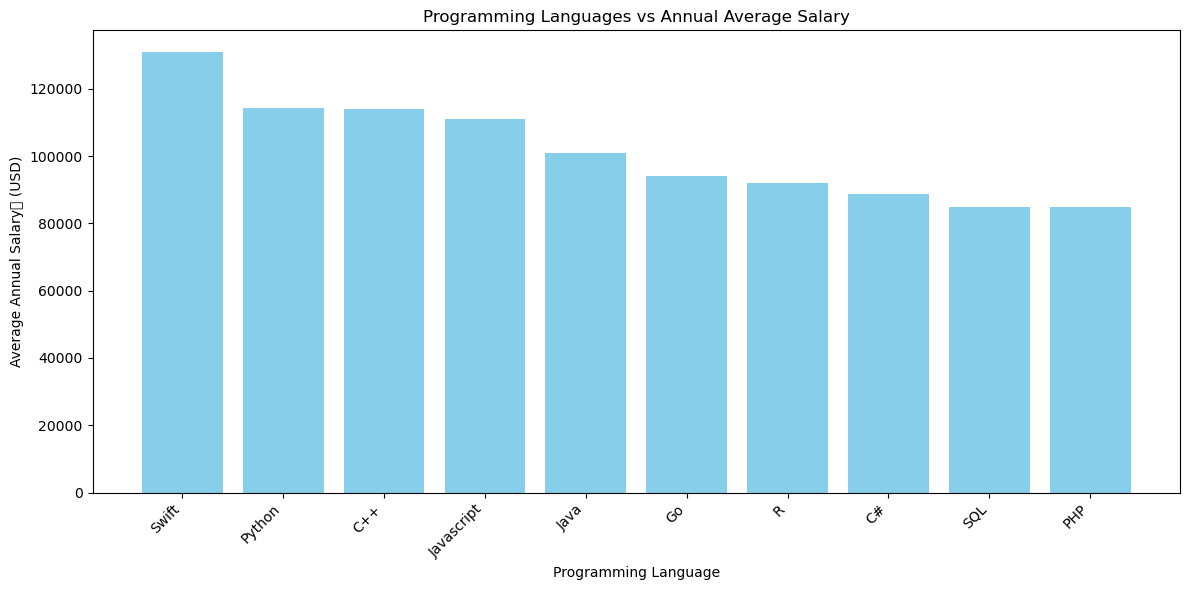

0    Language  Average Annual Salary
0       Swift                 130801
1      Python                 114383
2         C++                 113865
3  Javascript                 110981
4        Java                 101013


In [12]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import matplotlib.pyplot as plt

# URL
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

# Download webpage
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

# Find the first table
table = soup.find("table")

# Extract rows
rows = []
for tr in table.find_all("tr"):
    cells = tr.find_all(["td", "th"])  # include th in case there are no separate headers
    row = [cell.text.strip() for cell in cells]
    rows.append(row)

# Create DataFrame
df = pd.DataFrame(rows)
print(df.head())

# The first row contains the headers
df.columns = df.iloc[0]  # set first row as header
df = df[1:]              # remove first row from data
print(df.head())

# Keep only relevant columns
# Adjust column names if necessary (check df.columns)
df = df[["Language", "Average Annual Salary"]]

# Clean salary column
df["Average Annual Salary"] = df["Average Annual Salary"].str.replace("$", "", regex=False)
df["Average Annual Salary"] = df["Average Annual Salary"].str.replace(",", "", regex=False)
df["Average Annual Salary"] = pd.to_numeric(df["Average Annual Salary"], errors='coerce')

# Drop rows with NaN salaries
df = df.dropna(subset=["Average Annual Salary"])


# Sort descending
df_sorted = df.sort_values(by="Average Annual Salary", ascending=False).reset_index(drop=True)

# Save to CSV
df_sorted.to_csv("popular-languages.csv", index=False)

# Plot bar chart
plt.figure(figsize=(12, 6))
plt.bar(df_sorted["Language"], df_sorted["Average Annual Salary"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Programming Language")
plt.ylabel("Average Annual Salary	 (USD)")
plt.title("Programming Languages vs Annual Average Salary")
plt.tight_layout()
plt.show()

# Check data
print(df_sorted.head())


Ramesh Sannareddy


### Other Contributors


Rav Ahuja


## Change Log


|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2020-10-17  | 0.1  | Ramesh Sannareddy  |  Created initial version of the lab |


 Copyright &copy; 2020 IBM Corporation. This notebook and its source code are released under the terms of the [MIT License](https://cognitiveclass.ai/mit-license/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01).
